In [1]:

import numpy as np
from scipy.stats import norm
import yfinance as yf
import pandas as pd
import datetime
import time
import arch
from arch import arch_model
import matplotlib.pyplot as plt
from numba import jit
from sklearn.metrics import mean_squared_error as mse
import warnings
warnings.filterwarnings('ignore')

In [2]:
stocks = '^GSPC'
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime(2021, 8, 1)
s_p500 = yf.download(stocks, start=start, end=end, interval='1d')

[*********************100%***********************]  1 of 1 completed


In [3]:
ret = 100 * (s_p500.pct_change()[1:]['Adj Close'])
realized_vol = ret.rolling(5).std()

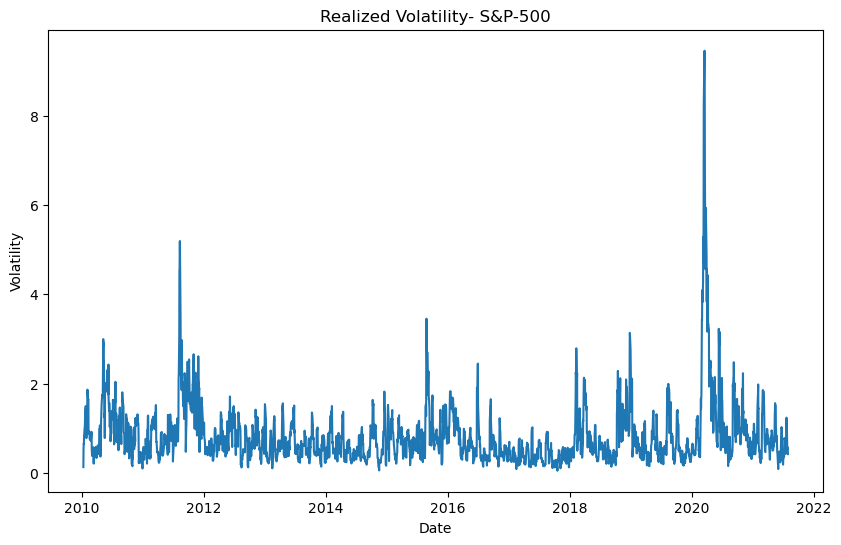

In [4]:
plt.figure(figsize=(10,6))
plt.plot(realized_vol.index,realized_vol)
plt.title('Realized Volatility- S&P-500')
plt.ylabel('Volatility')
plt.xlabel('Date')
plt.show()

In [5]:
retv = ret.values

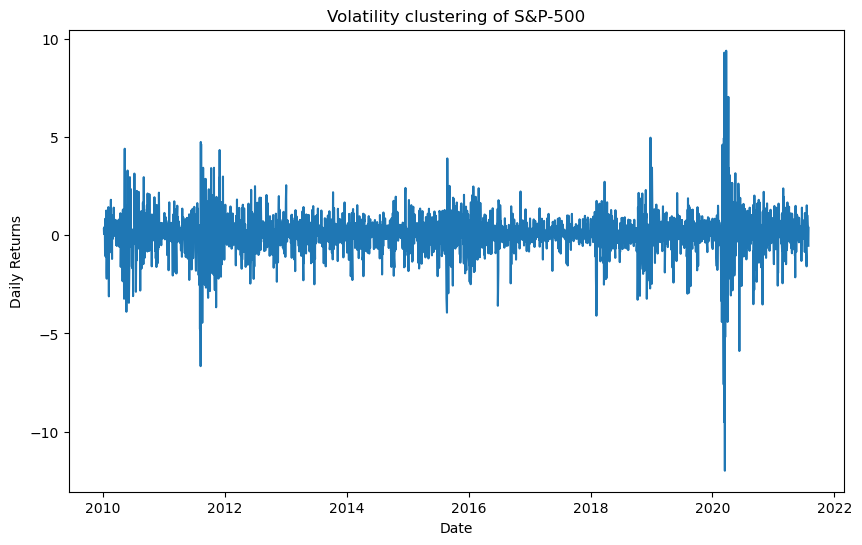

In [6]:
plt.figure(figsize=(10,6))
plt.plot(s_p500.index[1:],ret)
plt.title('Volatility clustering of S&P-500')
plt.ylabel('Daily Returns')
plt.xlabel('Date')
plt.show()

In [7]:
n = 252 
split_date = ret.iloc[-n:].index


In [8]:
sgm2 = ret.var()
k = ret.kurtosis()
alpha = (-3.0 * sgm2 + np.sqrt(9.0 * sgm2 ** 2 - 12.0 *
                               (3.0 * sgm2 - k) * k)) / (6* k)

omega = (1- alpha) * sgm2
initial_parameters = [alpha, omega]
omega, alpha

(0.634156491639156, 0.46673132307801635)

In [9]:
@jit(nopython=True, parallel=True)
def arch_likelihood(initial_parameters, retv):
    omega = abs(initial_parameters[0])
    alpha = abs(initial_parameters[1])
    T = len(retv)
    logliks = 0
    sigma2 = np.zeros(T)
    for t in range (1, T):
        sigma2[t] = omega + alpha * (retv[t-1]) **2
    epsilon = 1e-8  # small constant to avoid division by zero
    logliks = np.sum(0.5 * (np.log(sigma2 + epsilon) + retv **2 / (sigma2 + epsilon)))
    return logliks

logliks = arch_likelihood(initial_parameters, retv)
logliks


4855159.540737327

In [10]:
from scipy import optimize as opt
def opt_params(x0, retv):
    opt_result = opt.minimize(arch_likelihood, x0=x0, args=(retv), method='Nelder-Mead', options={'maxiter':5000})
    params = opt_result.x
    print('\nResults of Nelder-Mead minimization\n{}\n{}'
         .format(''.join(['-'] * 28), opt_result))
    print('\nResulting params = {}'.format(params))       
    return params


In [11]:
params = opt_params(initial_parameters, retv)



Results of Nelder-Mead minimization
----------------------------
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 4855092.419944806
             x: [ 7.015e-01  3.913e-01]
           nit: 30
          nfev: 58
 final_simplex: (array([[ 7.015e-01,  3.913e-01],
                       [ 7.016e-01,  3.913e-01],
                       [ 7.016e-01,  3.914e-01]]), array([ 4.855e+06,  4.855e+06,  4.855e+06]))

Resulting params = [0.70152949 0.39126701]


In [12]:
def arch_apply(ret):
    omega= params[0]
    alpha = params[1]
    T = len(ret)
    sigma2_arch = np.zeros(T + 1)
    sigma2_arch[0] = np.var(ret)
    for t in range(1, T):
        sigma2_arch[t] = omega + alpha * ret[t - 1] **2
    return sigma2_arch

In [13]:
sigma2_arch = arch_apply(ret)

In [14]:
arch = arch_model(ret, mean='zero', vol='ARCH', p=1).fit(disp='off')
print(arch.summary())

                        Zero Mean - ARCH Model Results                        
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -4061.27
Distribution:                  Normal   AIC:                           8126.54
Method:            Maximum Likelihood   BIC:                           8138.50
                                        No. Observations:                 2913
Date:                Thu, Jan 25 2024   Df Residuals:                     2913
Time:                        15:08:40   Df Model:                            0
                            Volatility Model                            
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
omega          0.7014  5.002e-02     14.023  1.129e-44 [  0.603,  0.79

In [15]:
bic_arch = []

for p in range(1, 5):
    arch = arch_model(ret, mean='zero', vol='ARCH', p=p)\
                .fit(disp='off')
    bic_arch.append(arch.bic)
    if arch.bic == np.min(bic_arch):
        best_param = p
    arch = arch_model(ret, mean='zero', vol='ARCH', p=best_param)\
                .fit(disp='off')
print(arch.summary())

forecast = arch.forecast(start=split_date[0])
forecast_arch = forecast

                        Zero Mean - ARCH Model Results                        
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -3709.51
Distribution:                  Normal   AIC:                           7429.03
Method:            Maximum Likelihood   BIC:                           7458.91
                                        No. Observations:                 2913
Date:                Thu, Jan 25 2024   Df Residuals:                     2913
Time:                        15:08:40   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.2794  2.580e-02     10.829  2.498e-27   [  0.22

In [16]:
rmse_arch = np.sqrt(mse(realized_vol[-n:] / 100,
                       np.sqrt(forecast_arch\
                              .variance.iloc[-len(split_date):]
                                            /100)))
print('The RMSE value of ARCH model is {:.4f}'.format(rmse_arch))


The RMSE value of ARCH model is 0.0896


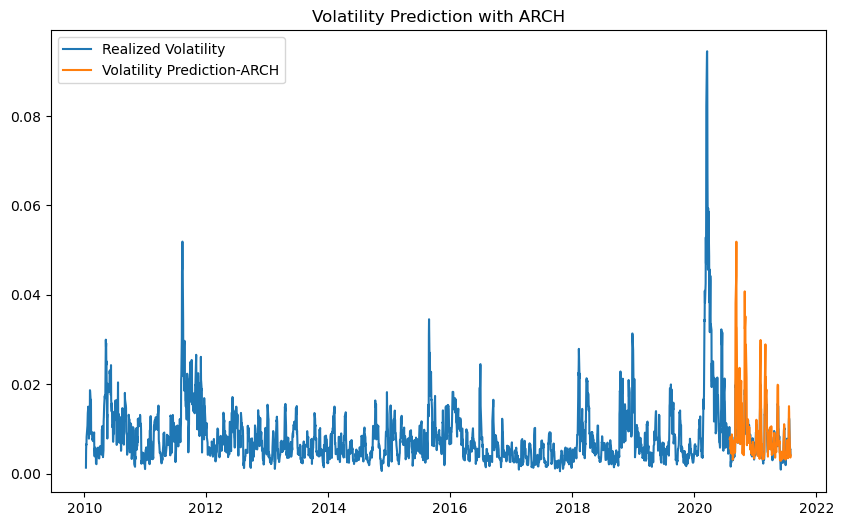

In [17]:
plt.figure(figsize=(10,6))
plt.plot(realized_vol/100, label='Realized Volatility')
plt.plot(forecast_arch.variance.iloc[-len(split_date):]/100,
        label='Volatility Prediction-ARCH')
plt.title('Volatility Prediction with ARCH', fontsize=12)
plt.legend()
plt.show()

In [18]:
bic_egarch = []

for p in range(1,5):
    for q in range(1,5):
        egarch = arch_model(ret, mean='zero', vol='EGARCH', p=p, q=q)\
                .fit(disp='off')
        bic_egarch.append(egarch.bic)
        if egarch.bic == np.min(bic_egarch):
            best_param = p, q
    egarch = arch_model(ret, mean='zero', vol='EGARCH',
                       p=best_param[0], q=best_param[1])\
            .fit(disp='off')

print(egarch.summary())
forecast = egarch.forecast(start=split_date[0])
forecast_egarch = forecast

                       Zero Mean - EGARCH Model Results                       
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -3673.53
Distribution:                  Normal   AIC:                           7353.05
Method:            Maximum Likelihood   BIC:                           7370.98
                                        No. Observations:                 2913
Date:                Thu, Jan 25 2024   Df Residuals:                     2913
Time:                        15:08:42   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      2.4573e-03  6.769e-03      0.363      0.717 

In [19]:
rmse_egarch = np.sqrt(mse(realized_vol[-n:] /100,
                         np.sqrt(forecast_egarch.variance\
                                .iloc[-len(split_date):]/100)))
print('The RMSE value of EGARCH models is {:.4f}'.format(rmse_egarch))


The RMSE value of EGARCH models is 0.0904


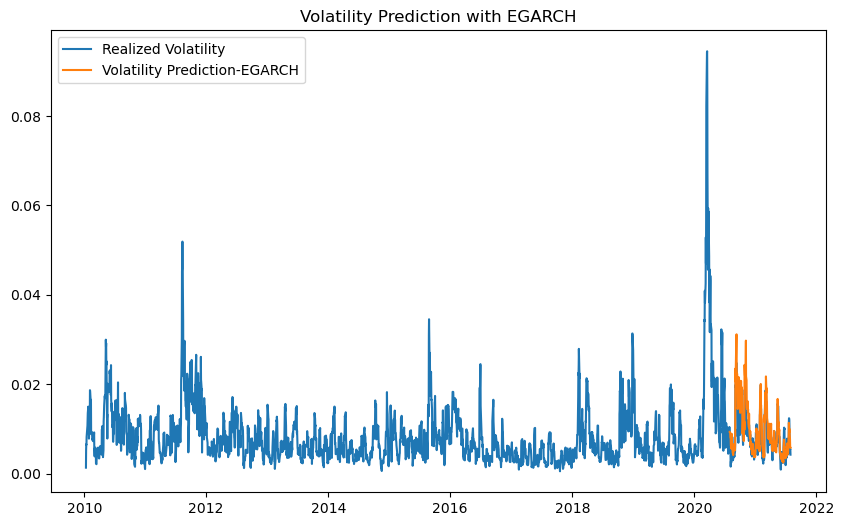

In [20]:
plt.figure(figsize=(10,6))
plt.plot(realized_vol /100, label="Realized Volatility")
plt.plot(forecast_egarch.variance.iloc[-len(split_date):]/100,
        label='Volatility Prediction-EGARCH')
plt.title('Volatility Prediction with EGARCH', fontsize=12)
plt.legend()
plt.show()

In [21]:
from sklearn.svm import SVR
from scipy.stats import uniform as sp_rand
from sklearn.model_selection import RandomizedSearchCV

In [22]:
realized_vol = ret.rolling(5).std()
realized_vol = pd.DataFrame(realized_vol)
realized_vol.reset_index(drop=True, inplace=True)

In [23]:
returns_svm = ret ** 2
returns_svm = returns_svm.reset_index()
del returns_svm['Date']

In [24]:
X = pd.concat([realized_vol, returns_svm], axis=1, ignore_index=True)
X = X[4:].copy()
X = X.reset_index()
X.drop('index', axis=1, inplace=True)

In [25]:
realized_vol = realized_vol.dropna().reset_index()
realized_vol.drop('index', axis=1, inplace=True)


In [26]:
svr_poly = SVR(kernel='poly', degree=2)
svr_lin = SVR(kernel='linear')
svr_rbf = SVR(kernel='rbf')

In [27]:
 para_grid = {'gamma': sp_rand(),
 'C': sp_rand(),
 'epsilon': sp_rand()}
 clf = RandomizedSearchCV(svr_lin, para_grid)
 clf.fit(X.iloc[:-n].values,
 realized_vol.iloc[1:-(n-1)].values.reshape(-1,))
 predict_svr_lin = clf.predict(X.iloc[-n:])


In [28]:
predict_svr_lin = pd.DataFrame(predict_svr_lin)
predict_svr_lin.index = ret.iloc[-n:].index

In [29]:
 rmse_svr = np.sqrt(mse(realized_vol.iloc[-n:] / 100,
 predict_svr_lin / 100))
print('The RMSE value of SVR with Linear Kernel is {:.6f}'
 .format(rmse_svr))


The RMSE value of SVR with Linear Kernel is 0.000672


In [30]:
realized_vol.index = ret.iloc[4:].index

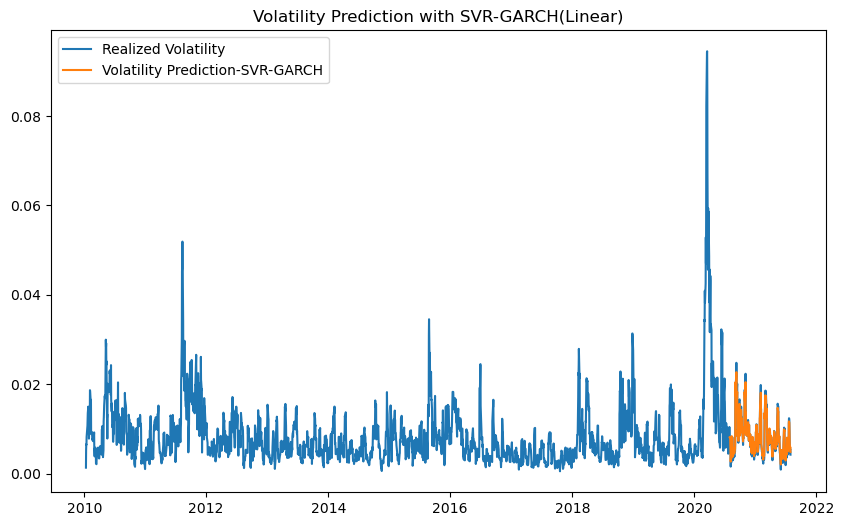

In [31]:
plt.figure(figsize=(10,6))
plt.plot(realized_vol /100, label='Realized Volatility')
plt.plot(predict_svr_lin /100, label='Volatility Prediction-SVR-GARCH')
plt.title('Volatility Prediction with SVR-GARCH(Linear)', fontsize=12)
plt.legend()
plt.show()

In [32]:
para_grid = {'gamma': sp_rand(),
            'C': sp_rand(),
            'epsilon': sp_rand()}
clf = RandomizedSearchCV(svr_rbf, para_grid)
clf.fit(X.iloc[:-n].values,
       realized_vol.iloc[1:-(n-1)].values.reshape(-1,))
predict_svr_rbf = clf.predict(X.iloc[-n:])

In [33]:
predict_svr_rbf = pd.DataFrame(predict_svr_rbf)
predict_svr_rbf.index = ret.iloc[-n:].index

In [34]:
rmse_svr_rbf = np.sqrt(mse(realized_vol.iloc[-n:]/100,
                          predict_svr_rbf / 100))
print('The RMSE value of SVR with RBF Kernel is {:.6f}'
      .format(rmse_svr_rbf))

The RMSE value of SVR with RBF Kernel is 0.000598


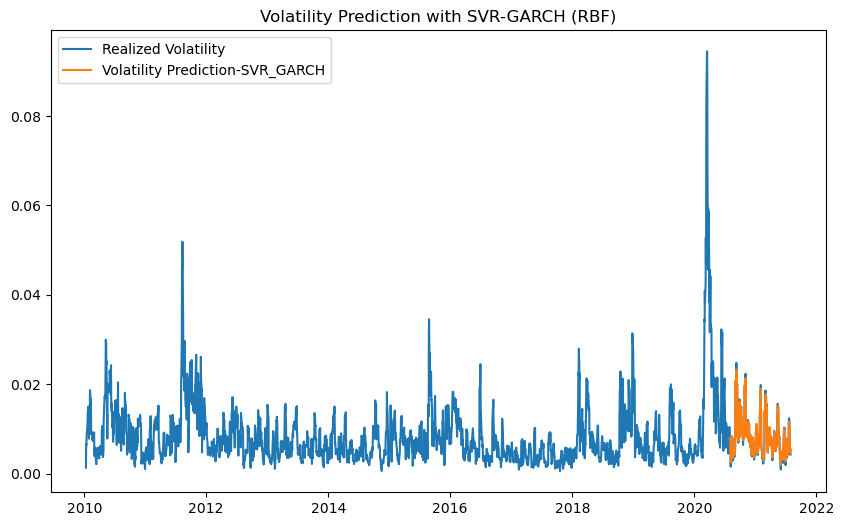

In [35]:
plt.figure(figsize=(10,6))
plt.plot(realized_vol /100, label='Realized Volatility')
plt.plot(predict_svr_rbf /100, label='Volatility Prediction-SVR_GARCH')
plt.title('Volatility Prediction with SVR-GARCH (RBF)', fontsize=12)
plt.legend()
plt.show()

In [36]:
from sklearn.neural_network import MLPRegressor

In [37]:
NN_vol = MLPRegressor(learning_rate_init= 0.001, random_state=1)
para_grid_NN = {'hidden_layer_sizes': [(100, 50), (50, 50), (10,100)],
               'max_iter':[500, 1000],
               'alpha':[0.00005, 0.0005]}

In [38]:
clf = RandomizedSearchCV(NN_vol, para_grid_NN)


In [39]:
clf.fit(X.iloc[:-n].values,
       realized_vol.iloc[1:-(n-1)].values.reshape(-1, ))


RandomizedSearchCV(estimator=MLPRegressor(random_state=1),
                   param_distributions={'alpha': [5e-05, 0.0005],
                                        'hidden_layer_sizes': [(100, 50),
                                                               (50, 50),
                                                               (10, 100)],
                                        'max_iter': [500, 1000]})

In [40]:
NN_predictions = clf.predict(X.iloc[-n:])

In [41]:
NN_predictions = pd.DataFrame(NN_predictions)

In [42]:
NN_predictions.index = ret.iloc[-n:].index

In [43]:
rmse_NN = np.sqrt(mse(realized_vol.iloc[-n:] / 100,
                     NN_predictions / 100))

In [44]:
print('The RMSE value of NN is {:.6f}'.format(rmse_NN))

The RMSE value of NN is 0.000647


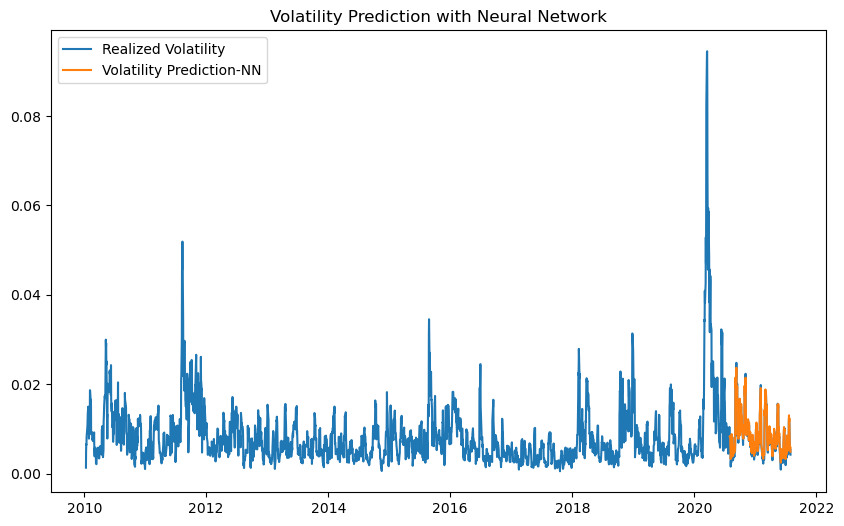

In [45]:
plt.figure(figsize = (10, 6))
plt.plot(realized_vol /100, label='Realized Volatility')
plt.plot(NN_predictions /100, label = 'Volatility Prediction-NN')
plt.title('Volatility Prediction with Neural Network', fontsize=12)
plt.legend()
plt.show()

In [46]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [47]:
model = keras.Sequential(
[layers.Dense(256, activation='relu'),
layers.Dense(128, activation='relu'),
layers.Dense(1, activation='linear'),])

In [48]:
model.compile(loss='mse', optimizer='rmsprop')

In [49]:
epochs_trial = np.arange(100, 400, 4)

In [50]:
batch_trial = np.arange(100, 400, 4)

In [51]:
epochs_trial = np.arange(100, 400, 4)
batch_trial = np.arange(100, 400, 4)
DL_pred = []
DL_RMSE = []

                               

In [52]:
for i, j, k in zip(range(4), epochs_trial, batch_trial):
    model.fit(X.iloc[:-n].values,
              realized_vol.iloc[1:-(n-1)].values.reshape(-1,),
              batch_size=k, epochs=j, verbose=False)
    DL_predict = model.predict(np.asarray(X.iloc[-n:]))
    DL_RMSE.append(np.sqrt(mse(realized_vol.iloc[-n:] /100,
                               DL_predict.flatten() / 100)))
    DL_pred.append(DL_predict)



8/8 [==============================] - 0s 2ms/step


In [53]:
print('DL_RMSE_{}:{:.6f}'.format(i+1, DL_RMSE[i]))

DL_RMSE_4:0.000993


In [54]:
DL_predict = pd.DataFrame(DL_pred[DL_RMSE.index(min(DL_RMSE))])
DL_predict.index = ret.iloc[-n:].index

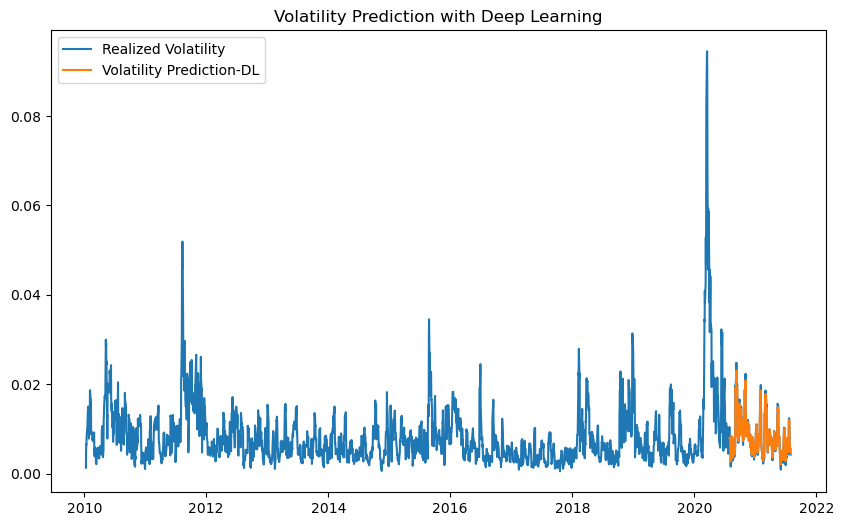

In [55]:
plt.figure(figsize=(10, 6))
plt.plot(realized_vol / 100, label='Realized Volatility')
plt.plot(DL_predict / 100, label='Volatility Prediction-DL')
plt.title('Volatility Prediction with Deep Learning', fontsize=12)
plt.legend()
plt.show()

In [56]:
!pip install quantecon

In [57]:
!pip install network
import quantecon as qe
from quantecon import MarkovChain
import network as nx
from pprint import pprint

In [58]:
p = [[0.5, 0.2, 0.3],
    [0.2, 0.3, 0.5],
    [0.2, 0.2, 0.6]]

In [59]:
mc = qe.MarkovChain(p,('studying', 'traveling', 'sleeping'))
mc.is_irreducible

True

In [60]:
states = ['studying', 'traveling','sleeping']
initial_probs = [0.5, 0.3, 0.6]
state_space = pd.Series(initial_probs, index=states, name='states')

In [61]:
q_df = pd.DataFrame(columns=states, index=states)
q_df = pd.DataFrame(columns=states, index=states)
q_df.loc[states[0]] = [0.5, 0.2, 0.3]
q_df.loc[states[1]] = [0.2, 0.3, 0.5]
q_df.loc[states[2]] = [0.2, 0.2, 0.6]

In [62]:
import quantecon as qe
from quantecon import MarkovChain
import networkx as nx
from pprint import pprint

In [63]:
P =[[0.5, 0.2, 0.3],
    [0.2, 0.3, 0.5],
    [0.2, 0.2, 0.6]]
mc = qe.MarkovChain(P, ('studying', 'travelling', 'sleeping'))
mc.is_irreducible

True

In [64]:
states = ['studying', 'travelling', 'sleeping']
initial_probs = [0.5, 0.3, 0.6]
state_space = pd.Series(initial_probs, index=states, name='states')

In [65]:
q_df = pd.DataFrame(columns=states, index=states)
q_df = pd.DataFrame(columns=states, index=states)
q_df.loc[states[0]] = [0.5, 0.2, 0.3]
q_df.loc[states[1]] = [0.2, 0.3, 0.5]
q_df.loc[states[2]] = [0.2, 0.2, 0.6]

In [66]:
def _get_markov_edges(Q):
    edges = {}
    for col in Q.columns:
        for idx in Q.columns:
            edges[(idx,col)] = Q.loc[idx, col]
    return edges 
edges_wts = _get_markov_edges(q_df)
pprint(edges_wts)
{('sleeping','sleeping'):0.6,
('sleeping', 'studying'):0.2,
('sleeping', 'travelling'):0.2,
('studying','sleeping'):0.3,
('studying', 'studying'):0.5,
('studying', 'travelling'):0.2,
('travelling','studying'):0.5,
('travelling', 'sleeping'):0.2,
('travelling', 'travelling'):0.3}


{('sleeping', 'sleeping'): 0.6,
 ('sleeping', 'studying'): 0.2,
 ('sleeping', 'travelling'): 0.2,
 ('studying', 'sleeping'): 0.3,
 ('studying', 'studying'): 0.5,
 ('studying', 'travelling'): 0.2,
 ('travelling', 'sleeping'): 0.5,
 ('travelling', 'studying'): 0.2,
 ('travelling', 'travelling'): 0.3}


{('sleeping', 'sleeping'): 0.6,
 ('sleeping', 'studying'): 0.2,
 ('sleeping', 'travelling'): 0.2,
 ('studying', 'sleeping'): 0.3,
 ('studying', 'studying'): 0.5,
 ('studying', 'travelling'): 0.2,
 ('travelling', 'studying'): 0.5,
 ('travelling', 'sleeping'): 0.2,
 ('travelling', 'travelling'): 0.3}

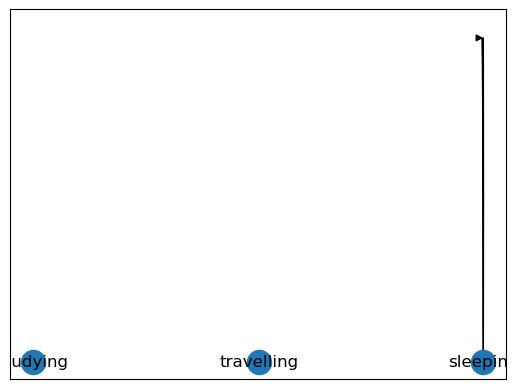

In [72]:
G = nx.MultiDiGraph()
G.add_nodes_from(states)
for k, v in edges_wts.items():
    tmp_origin, tmp_destination = k[0], k[1]
G.add_edge(tmp_origin, tmp_destination, weight=str(v), label=str(v))
 
pos = nx.drawing.nx_pydot.graphviz_layout(G, prog='dot')
nx.draw_networkx(G, pos)
edge_labels = {(n1, n2):d['label'] for n1, n2, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G , pos, edge_labels=edge_labels)
nx.drawing.nx_pydot.write_dot(G, 'mc_states.dot')
